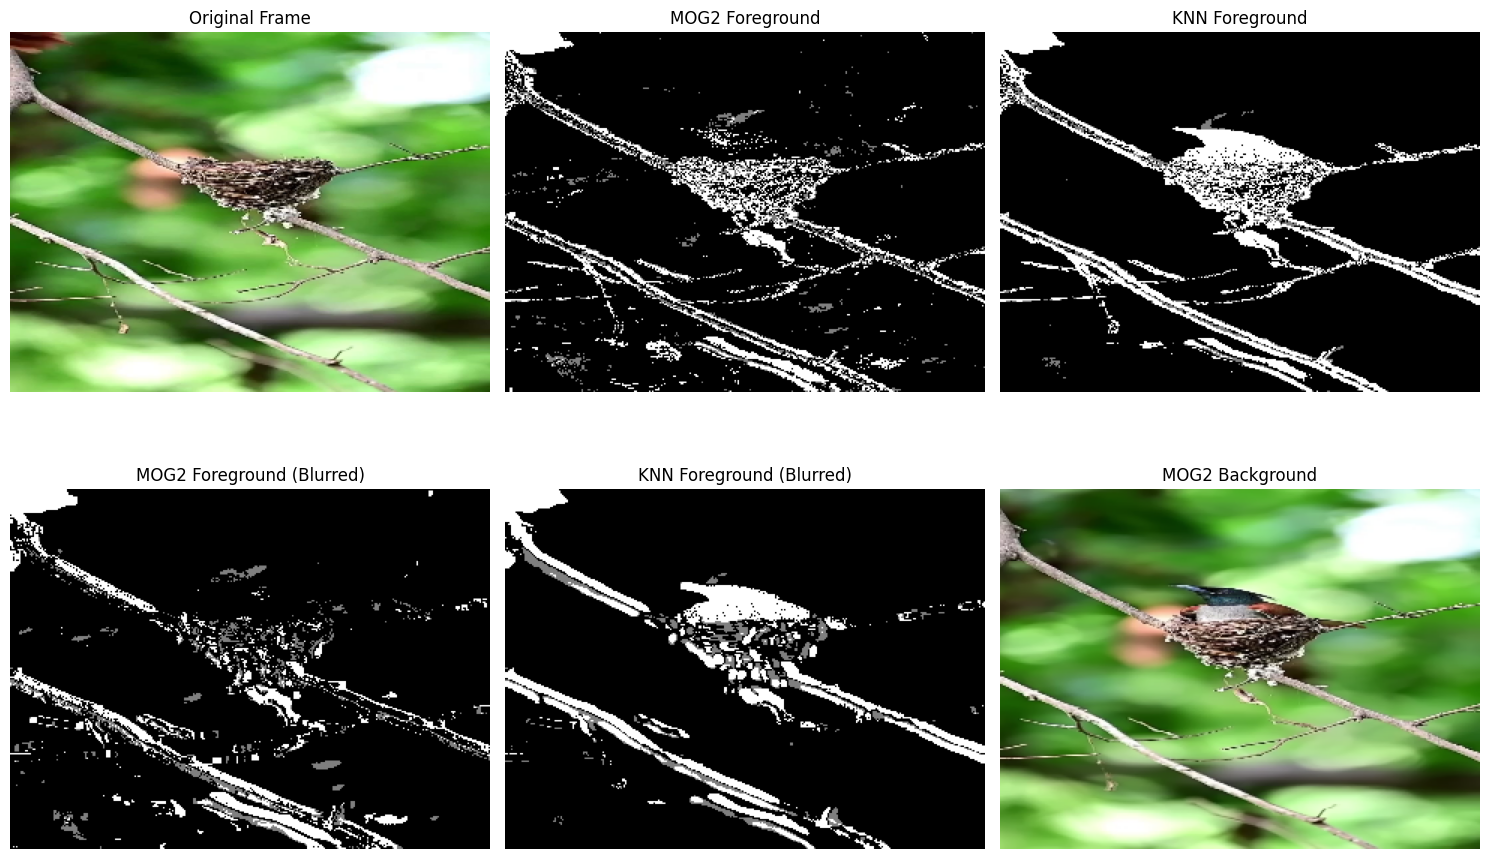

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(r'c:\Users\지우\Desktop\AI_study\cv_and_ml_with_python_and_opencv\video1_3sec.mp4')

if not cap.isOpened():
    print("비디오 파일을 열 수 없습니다.")
else:
    bgMethod1 = cv2.createBackgroundSubtractorMOG2()
    bgMethod2 = cv2.createBackgroundSubtractorKNN()
    bgMethod1_blur = cv2.createBackgroundSubtractorMOG2()
    bgMethod2_blur = cv2.createBackgroundSubtractorKNN()
    
    imgIndex = 1
    frame = None
    bgMOG = None
    bgKNN = None
    
    while cap.isOpened():
        ret, temp_frame = cap.read()
        if not ret or temp_frame is None:
            break
        
        frame = temp_frame  # 유효한 프레임만 저장
        frame = cv2.resize(frame, (320, 240))
        
        fgMOG = bgMethod1.apply(frame, learningRate=-1)
        fgKNN = bgMethod2.apply(frame)
        fgMOG_blur = bgMethod1_blur.apply(cv2.blur(frame, (5, 5)), learningRate=-1)
        fgKNN_blur = bgMethod2_blur.apply(cv2.blur(frame, (5, 5)))
        
        if imgIndex > 1:
            bgMOG = bgMethod1.getBackgroundImage()
            bgKNN = bgMethod2.getBackgroundImage()
            bgMOG_blur = bgMethod1_blur.getBackgroundImage()
            bgKNN_blur = bgMethod2_blur.getBackgroundImage()
        
        imgIndex += 1

    cap.release()

    # 결과 표시 (마지막 프레임 기준)
    if frame is not None:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes[0, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Original Frame')
        axes[0, 1].imshow(fgMOG, cmap='gray')
        axes[0, 1].set_title('MOG2 Foreground')
        axes[0, 2].imshow(fgKNN, cmap='gray')
        axes[0, 2].set_title('KNN Foreground')
        axes[1, 0].imshow(fgMOG_blur, cmap='gray')
        axes[1, 0].set_title('MOG2 Foreground (Blurred)')
        axes[1, 1].imshow(fgKNN_blur, cmap='gray')
        axes[1, 1].set_title('KNN Foreground (Blurred)')
        if bgMOG is not None:
            axes[1, 2].imshow(cv2.cvtColor(bgMOG, cv2.COLOR_BGR2RGB))
            axes[1, 2].set_title('MOG2 Background')
        for ax in axes.flat:
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("프레임을 읽을 수 없습니다.")

In [3]:
img1 = cv2.imread('./img8.jpg', cv2.IMREAD_UNCHANGED)
data = img1.reshape((-1, 3))
data = np.float32(data)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
attempts = 10
flags = cv2.KMEANS_RANDOM_CENTERS
for i in range(1, 3):
    numK = i * 5
    ret, label, center = cv2.kmeans(data, numK, None, criteria, attempts, flags)
    center = np.uint8(center)
    res = center[label.flatten()]
    res = res.reshape((img1.shape))

(np.float64(-0.5), np.float64(549.5), np.float64(349.5), np.float64(-0.5))

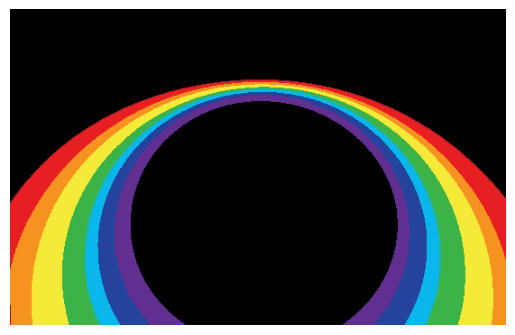

In [5]:
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [12]:
img1 = cv2.imread('./img8.jpg', cv2.IMREAD_UNCHANGED)
data = img1.reshape((-1, 3))
data = np.float32(data)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
attempts = 3
flags = cv2.KMEANS_RANDOM_CENTERS
for i in range(1, 3):
    numK = i * 5
    ret, label, center = cv2.kmeans(data, numK, None, criteria, attempts, flags)
    center = np.uint8(center)
    res = center[label.flatten()]
    res = res.reshape((img1.shape))

(np.float64(-0.5), np.float64(549.5), np.float64(349.5), np.float64(-0.5))

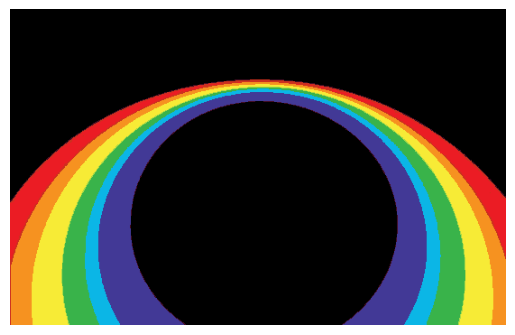

In [13]:
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [3]:
import cv2
import numpy as np
from pathlib import Path

img3 = cv2.imread('./img9.jpg', cv2.IMREAD_UNCHANGED)

h, w, c  = img3.shape

stepW = int(w/3)
overlap = int(stepW*0.3)

sp1 = img3[:, :stepW + overlap, :]
sp2 = img3[:, stepW - overlap : (stepW*2) + overlap, :]
sp3 = img3[:, (stepW*2) - overlap:, :]

sp1 = cv2.resize(sp1, (320, 240))
sp2 = cv2.resize(sp2, (320, 240))
sp3 = cv2.resize(sp3, (320, 240))

imgs1 = []
imgs1.append(sp1)
imgs1.append(sp2)

imgs2 = []
imgs2.append(sp2)
imgs2.append(sp3)

imgs3 = []
imgs3.append(sp1)
imgs3.append(sp2)
imgs3.append(sp3)

stitcher = cv2.Stitcher.create(cv2.STITCHER_PANORAMA)
status1, pano1 = stitcher.stitch(imgs1)
if status1 != cv2.Stitcher_OK:
    print("Can't stitch imgs1, error code = %d" % status1)
    exit(-1)

status2, pano2 = stitcher.stitch(imgs2)
if status2 != cv2.Stitcher_OK:
    print("Can't stitch imgs2, error code = %d" % status2)
    exit(-1)

status3, pano3 = stitcher.stitch(imgs3)
if status3 != cv2.Stitcher_OK:
    print("Can't stitch imgs3, error code = %d" % status3)
    exit(-1)

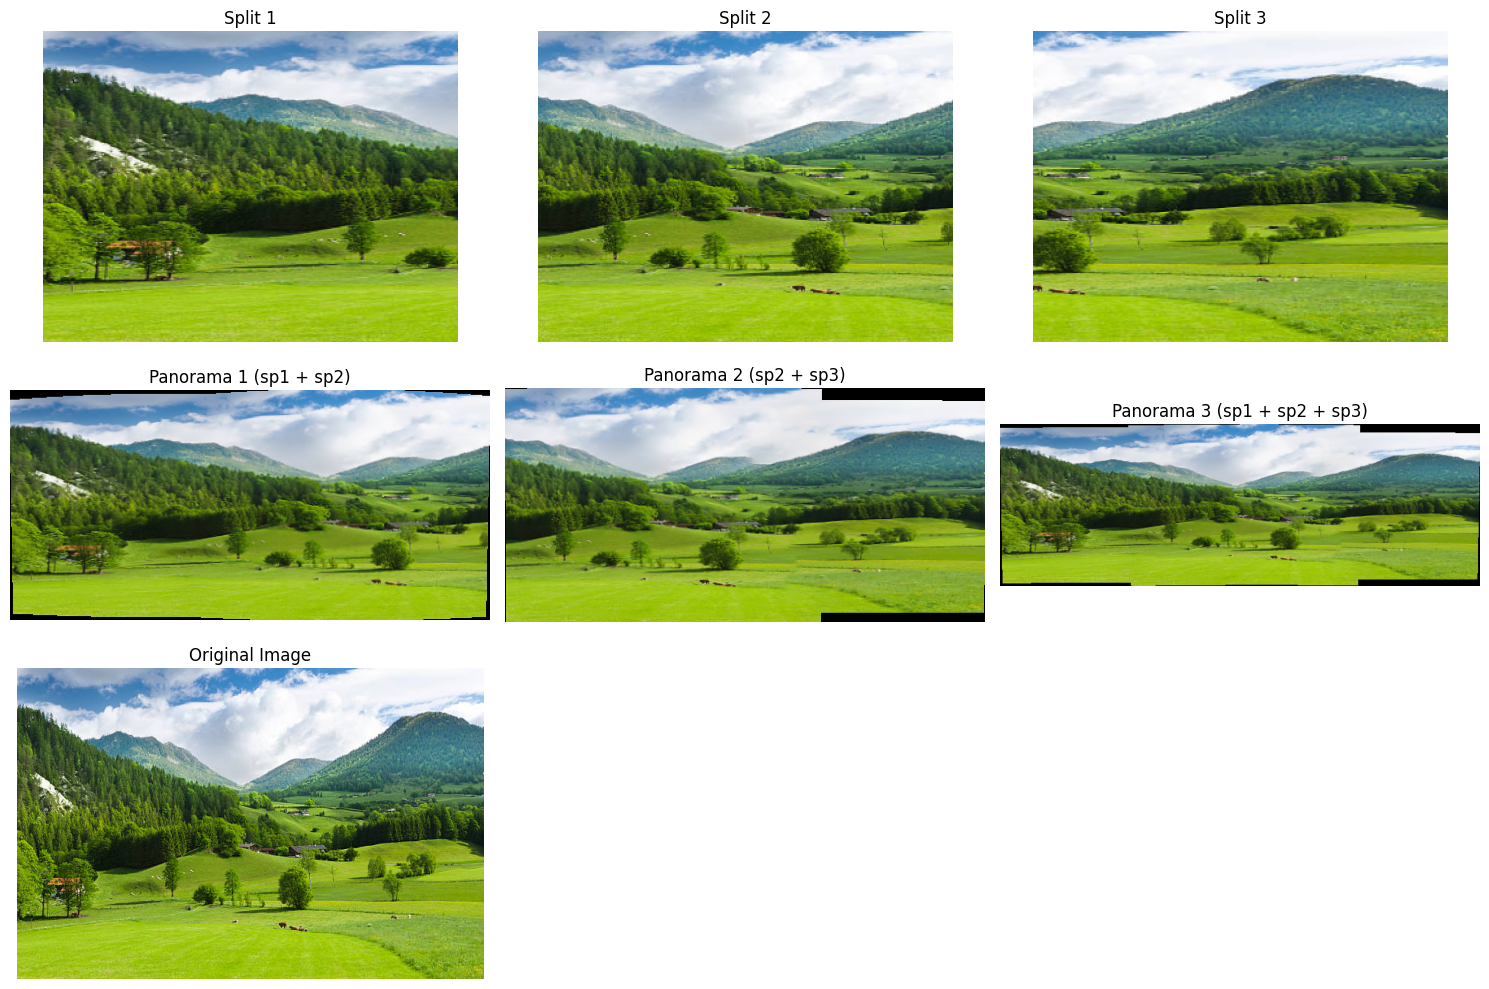

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# 첫 번째 행: 분할된 이미지들
axes[0, 0].imshow(cv2.cvtColor(sp1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Split 1')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(sp2, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Split 2')
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.cvtColor(sp3, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('Split 3')
axes[0, 2].axis('off')

# 두 번째 행: 스티칭된 파노라마 이미지들
axes[1, 0].imshow(cv2.cvtColor(pano1, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Panorama 1 (sp1 + sp2)')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(pano2, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Panorama 2 (sp2 + sp3)')
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.cvtColor(pano3, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Panorama 3 (sp1 + sp2 + sp3)')
axes[1, 2].axis('off')

# 세 번째 행: 원본 이미지
axes[2, 0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[2, 0].set_title('Original Image')
axes[2, 0].axis('off')

# 나머지 빈 subplot 제거
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()